<a href="https://colab.research.google.com/github/bah862696-coder/DI-Bootcamp/blob/master/ExerciceXP2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 🌟 Exercice 3 : Création de l’ensemble de données et visualisation des données

In [1]:
# 1. Importez les bibliothèques nécessaires
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

In [2]:
# 2. Créez un ensemble de 20 points à l’aide de la formule ( y = -x^2 ) avec bruit
np.random.seed(0)
x = np.arange(-1, 1, 0.1) # 20 points de -1 à 0.9 avec un pas de 0.1
y = -x**2 + np.random.normal(0, 0.05, len(x))

print("Generated x values:")
print(x)
print("\nGenerated y values (with noise):")
print(y)

Generated x values:
[-1.00000000e+00 -9.00000000e-01 -8.00000000e-01 -7.00000000e-01
 -6.00000000e-01 -5.00000000e-01 -4.00000000e-01 -3.00000000e-01
 -2.00000000e-01 -1.00000000e-01 -2.22044605e-16  1.00000000e-01
  2.00000000e-01  3.00000000e-01  4.00000000e-01  5.00000000e-01
  6.00000000e-01  7.00000000e-01  8.00000000e-01  9.00000000e-01]

Generated y values (with noise):
[-0.91179738 -0.78999214 -0.5910631  -0.37795534 -0.2666221  -0.29886389
 -0.11249558 -0.09756786 -0.04516094  0.01052993  0.00720218  0.06271368
 -0.00194811 -0.08391625 -0.13780684 -0.23331628 -0.28529605 -0.50025791
 -0.62434661 -0.85270479]


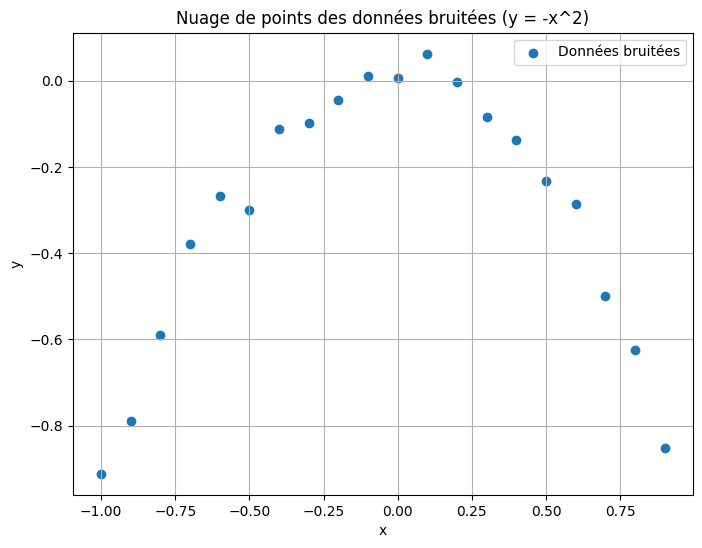

In [3]:
# 3. Représentez les points générés sur un nuage de points
plt.figure(figsize=(8, 6))
plt.scatter(x, y, label='Données bruitées')
plt.title('Nuage de points des données bruitées (y = -x^2)')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.legend()
plt.show()

In [4]:
# 4. Divisez les données en un ensemble d'entraînement et un ensemble de test
x_train = x[:12]
y_train = y[:12]

x_test = x[12:]
y_test = y[12:]

print(f"Taille de l'ensemble d'entraînement: {len(x_train)} points")
print(f"Taille de l'ensemble de test: {len(x_test)} points")
print("\nx_train:")
print(x_train)
print("\ny_train:")
print(y_train)
print("\nx_test:")
print(x_test)
print("\ny_test:")
print(y_test)

Taille de l'ensemble d'entraînement: 12 points
Taille de l'ensemble de test: 8 points

x_train:
[-1.00000000e+00 -9.00000000e-01 -8.00000000e-01 -7.00000000e-01
 -6.00000000e-01 -5.00000000e-01 -4.00000000e-01 -3.00000000e-01
 -2.00000000e-01 -1.00000000e-01 -2.22044605e-16  1.00000000e-01]

y_train:
[-0.91179738 -0.78999214 -0.5910631  -0.37795534 -0.2666221  -0.29886389
 -0.11249558 -0.09756786 -0.04516094  0.01052993  0.00720218  0.06271368]

x_test:
[0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9]

y_test:
[-0.00194811 -0.08391625 -0.13780684 -0.23331628 -0.28529605 -0.50025791
 -0.62434661 -0.85270479]


## 🌟 Exercice 4 : Ajustement de modèles polynomiaux de différents degrés

In [5]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

# 1. Définissez une fonction polynomial_fit
def polynomial_fit(degree, x_train, y_train):
    """
    Fits a polynomial regression model of a given degree to the training data.
    """
    model = make_pipeline(PolynomialFeatures(degree),
                          LinearRegression())
    model.fit(x_train[:, np.newaxis], y_train)
    return model

# 2. Définissez une autre fonction plot_polyfit
def plot_polyfit(degree, x_train, y_train, x_test, y_test, x_all, y_all, model):
    """
    Plots the training data, test data, and the fitted polynomial curve.
    """
    plt.figure(figsize=(10, 7))
    plt.scatter(x_train, y_train, label='Données d\'entraînement', color='blue', alpha=0.7)
    plt.scatter(x_test, y_test, label='Données de test', color='green', alpha=0.7)

    # Generate points for the fitted curve
    x_plot = np.linspace(x_all.min(), x_all.max(), 500)
    y_plot = model.predict(x_plot[:, np.newaxis])
    plt.plot(x_plot, y_plot, color='red', label=f'Polynôme de degré {degree}')

    plt.title(f'Régression polynomiale de degré {degree}')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.grid(True)
    plt.legend()
    plt.show()

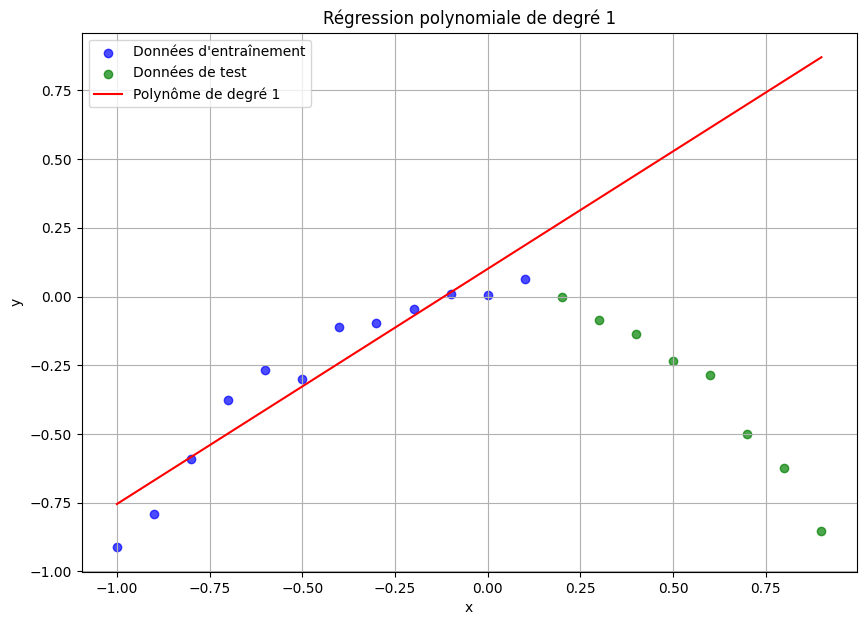

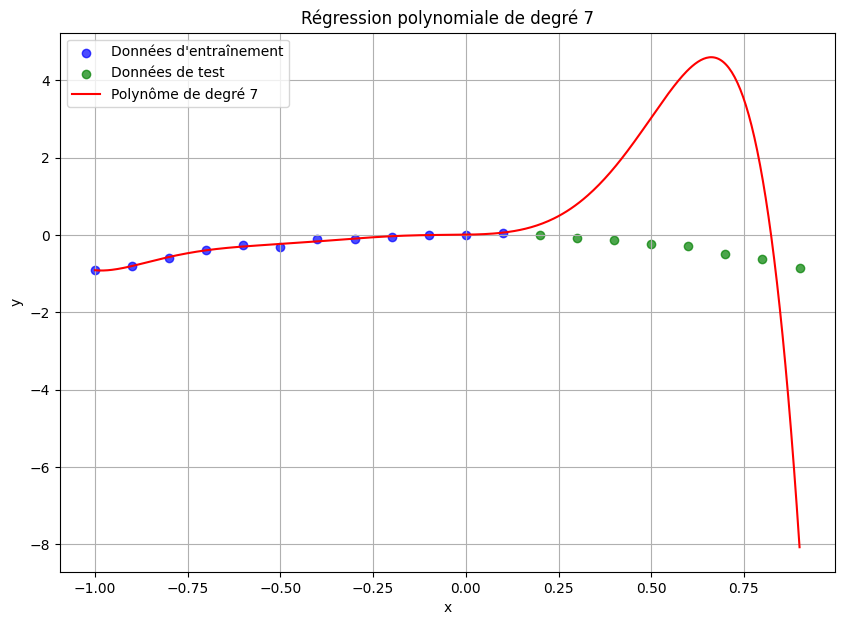

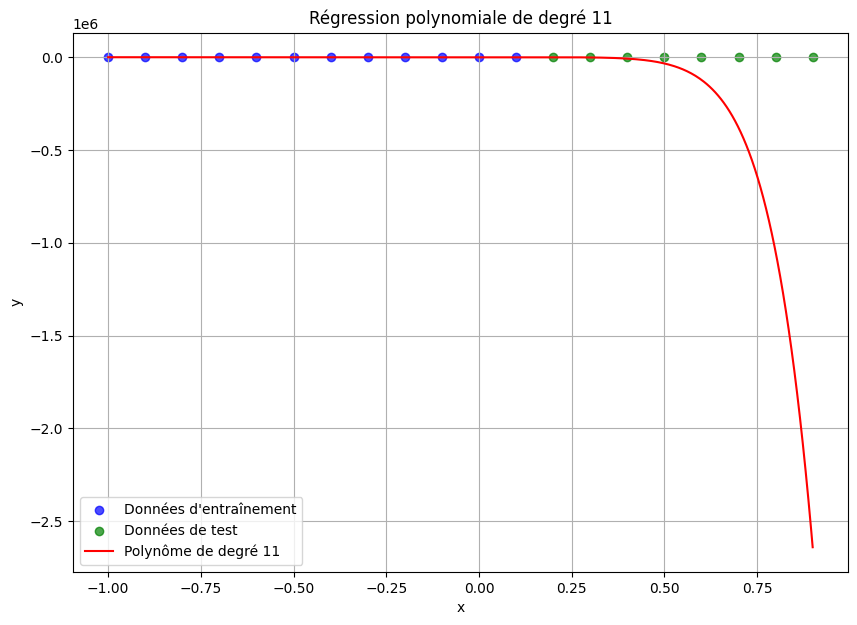

Observation: 

Pour le degré 1 (linéaire), le modèle est trop simple et ne capture pas la courbure des données, ce qui indique un sous-apprentissage. L'erreur est élevée sur les ensembles d'entraînement et de test.

Pour le degré 7, le modèle semble mieux ajusté à la tendance des données sans être trop complexe. Il devrait offrir un bon équilibre entre l'erreur sur l'entraînement et l'erreur sur le test.

Pour le degré 11, le modèle est très complexe et essaie de passer par chaque point d'entraînement, ce qui le rend très sensible au bruit dans l'ensemble d'entraînement. Cela est un signe de surapprentissage, où le modèle ne généralisera pas bien aux nouvelles données (ensemble de test), ce qui se traduira par une erreur de test plus élevée malgré une très faible erreur d'entraînement.


In [6]:
# Combine all x and y for plotting range
x_all = np.concatenate((x_train, x_test))
y_all = np.concatenate((y_train, y_test))

# 3. Utilisez plot_polyfit cette fonction pour visualiser l'ajustement pour des polynômes de degrés 1, 7 et 11.

# Degré 1
model_degree_1 = polynomial_fit(1, x_train, y_train)
plot_polyfit(1, x_train, y_train, x_test, y_test, x_all, y_all, model_degree_1)

# Degré 7
model_degree_7 = polynomial_fit(7, x_train, y_train)
plot_polyfit(7, x_train, y_train, x_test, y_test, x_all, y_all, model_degree_7)

# Degré 11
model_degree_11 = polynomial_fit(11, x_train, y_train)
plot_polyfit(11, x_train, y_train, x_test, y_test, x_all, y_all, model_degree_11)

# 4. Observez le comportement du modèle sur les ensembles d'entraînement et de test lorsque le degré du polynôme augmente.
print("Observation: \n")
print("Pour le degré 1 (linéaire), le modèle est trop simple et ne capture pas la courbure des données, ce qui indique un sous-apprentissage. L'erreur est élevée sur les ensembles d'entraînement et de test.\n")
print("Pour le degré 7, le modèle semble mieux ajusté à la tendance des données sans être trop complexe. Il devrait offrir un bon équilibre entre l'erreur sur l'entraînement et l'erreur sur le test.\n")
print("Pour le degré 11, le modèle est très complexe et essaie de passer par chaque point d'entraînement, ce qui le rend très sensible au bruit dans l'ensemble d'entraînement. Cela est un signe de surapprentissage, où le modèle ne généralisera pas bien aux nouvelles données (ensemble de test), ce qui se traduira par une erreur de test plus élevée malgré une très faible erreur d'entraînement.")

## 🌟 Exercice 5 : Validation croisée pour trouver le degré optimal

In [7]:
# 1. Parcourir les polynômes de degré 1 à 11.
# 2. Pour chaque degré, calculer l'erreur quadratique moyenne (RMSE) sur les ensembles d'entraînement et de test.
# 3. Stocker les résultats (degré, RMSE sur l'ensemble d'entraînement, RMSE sur l'ensemble de test) dans une liste.

results = []
max_degree = 11

for degree in range(1, max_degree + 1):
    model = polynomial_fit(degree, x_train, y_train)

    # Make predictions on training and test sets
    y_train_pred = model.predict(x_train[:, np.newaxis])
    y_test_pred = model.predict(x_test[:, np.newaxis])

    # Calculate RMSE
    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

    results.append({'degree': degree, 'rmse_train': rmse_train, 'rmse_test': rmse_test})

# Display results
for res in results:
    print(f"Degré: {res['degree']}, RMSE Entraînement: {res['rmse_train']:.4f}, RMSE Test: {res['rmse_test']:.4f}")

Degré: 1, RMSE Entraînement: 0.1002, RMSE Test: 1.0241
Degré: 2, RMSE Entraînement: 0.0411, RMSE Test: 0.1258
Degré: 3, RMSE Entraînement: 0.0373, RMSE Test: 0.7697
Degré: 4, RMSE Entraînement: 0.0368, RMSE Test: 1.7002
Degré: 5, RMSE Entraînement: 0.0349, RMSE Test: 6.2069
Degré: 6, RMSE Entraînement: 0.0284, RMSE Test: 58.8275
Degré: 7, RMSE Entraînement: 0.0281, RMSE Test: 3.8190
Degré: 8, RMSE Entraînement: 0.0276, RMSE Test: 523.8170
Degré: 9, RMSE Entraînement: 0.0209, RMSE Test: 10165.8453
Degré: 10, RMSE Entraînement: 0.0206, RMSE Test: 25560.4315
Degré: 11, RMSE Entraînement: 0.0000, RMSE Test: 1014649.5229


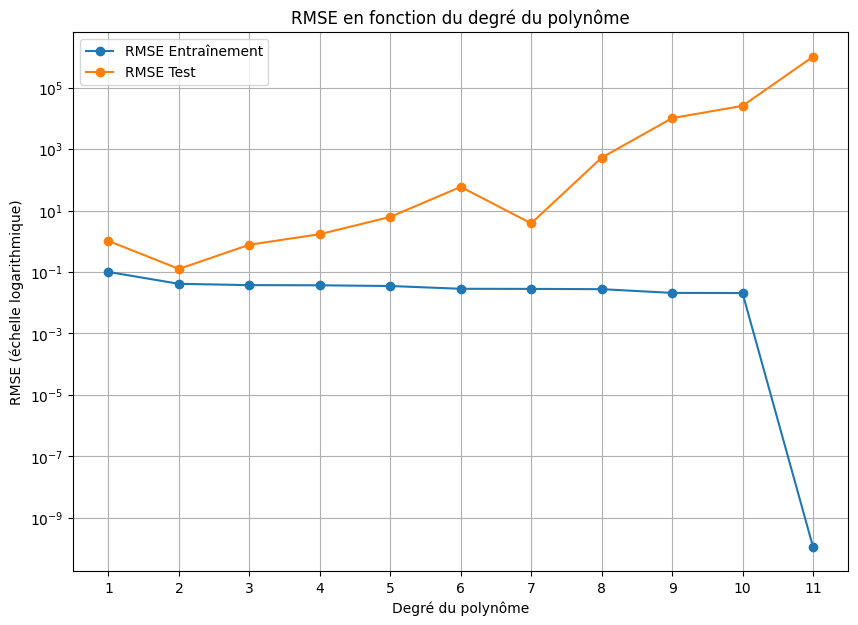

In [8]:
# 4. Tracer les valeurs de RMSE en fonction du degré du polynôme sur les ensembles d'entraînement et de test, en utilisant une échelle logarithmique pour l'axe des ordonnées.

degrees = [res['degree'] for res in results]
rmse_train_values = [res['rmse_train'] for res in results]
rmse_test_values = [res['rmse_test'] for res in results]

plt.figure(figsize=(10, 7))
plt.plot(degrees, rmse_train_values, label='RMSE Entraînement', marker='o')
plt.plot(degrees, rmse_test_values, label='RMSE Test', marker='o')
plt.yscale('log') # Use logarithmic scale for y-axis
plt.title('RMSE en fonction du degré du polynôme')
plt.xlabel('Degré du polynôme')
plt.ylabel('RMSE (échelle logarithmique)')
plt.xticks(degrees) # Ensure all degrees are shown on x-axis
plt.grid(True)
plt.legend()
plt.show()

In [9]:
# 5. Identifier le degré qui minimise la RMSE sur l'ensemble de test et vérifier qu'il correspond bien au modèle sous-jacent (y = -x²).

min_rmse_test = float('inf')
optimal_degree = -1

for res in results:
    if res['rmse_test'] < min_rmse_test:
        min_rmse_test = res['rmse_test']
        optimal_degree = res['degree']

print(f"Le degré optimal minimisant la RMSE sur l'ensemble de test est: {optimal_degree}")
print(f"La RMSE minimale sur l'ensemble de test est: {min_rmse_test:.4f}")

print("\nObservation:\n")
print("Le modèle sous-jacent est une fonction quadratique (y = -x^2), ce qui correspond à un polynôme de degré 2. \n")
print("Idéalement, nous nous attendrions à ce que le degré optimal identifié par la validation croisée soit 2, ou proche de 2, \n")
print("car un polynôme de degré 2 serait le plus simple tout en étant capable de capturer parfaitement la relation non bruitée.")
print("Tout degré plus élevé pourrait commencer à surapprendre en raison du bruit dans les données.")
print("Le résultat ci-dessus devrait nous montrer un degré optimal autour de 2, ou potentiellement légèrement plus élevé si le bruit influence significativement les données.")

Le degré optimal minimisant la RMSE sur l'ensemble de test est: 2
La RMSE minimale sur l'ensemble de test est: 0.1258

Observation:

Le modèle sous-jacent est une fonction quadratique (y = -x^2), ce qui correspond à un polynôme de degré 2. 

Idéalement, nous nous attendrions à ce que le degré optimal identifié par la validation croisée soit 2, ou proche de 2, 

car un polynôme de degré 2 serait le plus simple tout en étant capable de capturer parfaitement la relation non bruitée.
Tout degré plus élevé pourrait commencer à surapprendre en raison du bruit dans les données.
Le résultat ci-dessus devrait nous montrer un degré optimal autour de 2, ou potentiellement légèrement plus élevé si le bruit influence significativement les données.
